<a href="https://colab.research.google.com/github/jabousleiman/case-b-battery-coursework/blob/main/caseB_battery_arbitrage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total profit (£): 9598.33
Charged energy (kWh): 122537.52
Discharged energy (kWh): 107112.37
Energy throughput (kWh): 229649.89
Initial SOC (kWh): 1000.0
Final SOC (kWh): 1747.9
SOC within bounds: True
Charge within bounds: True
Discharge within bounds: True


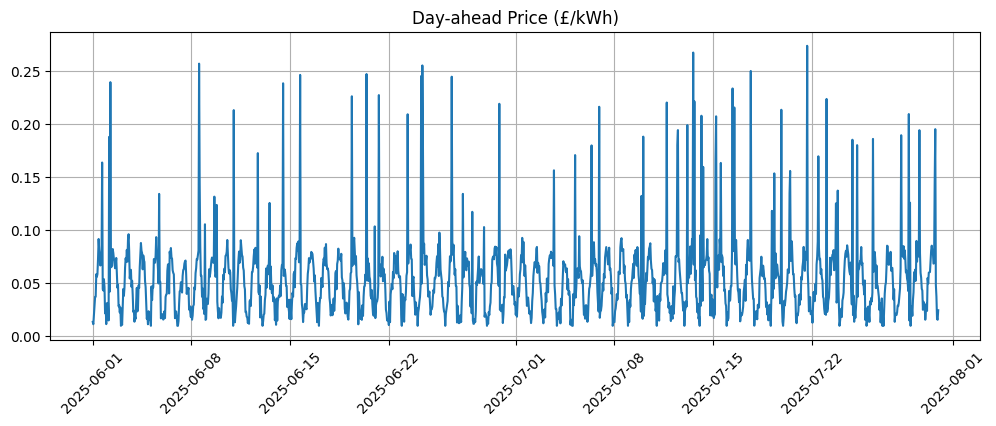

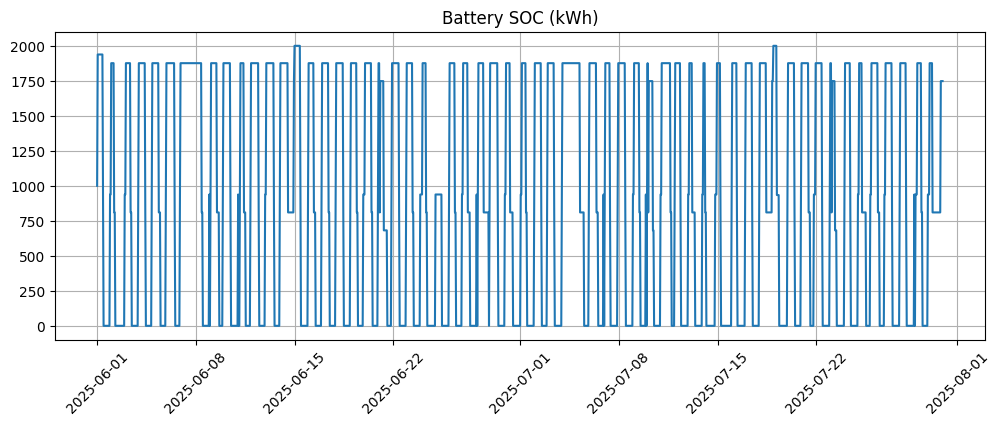

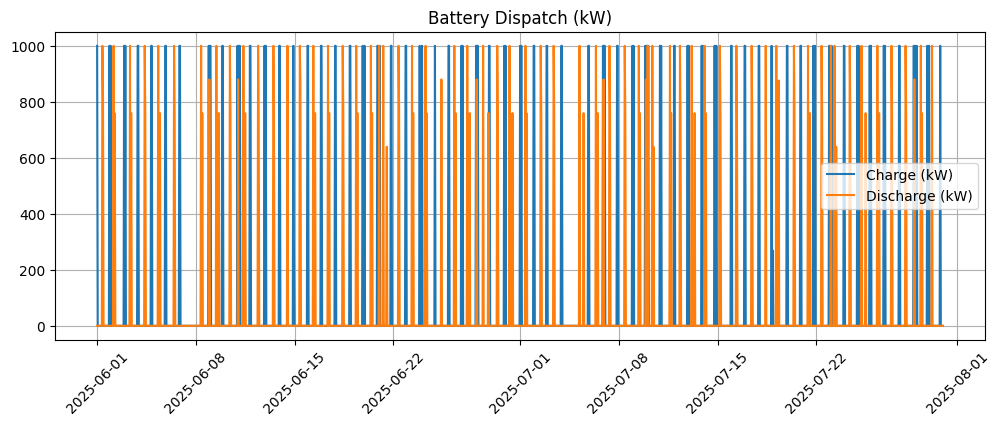

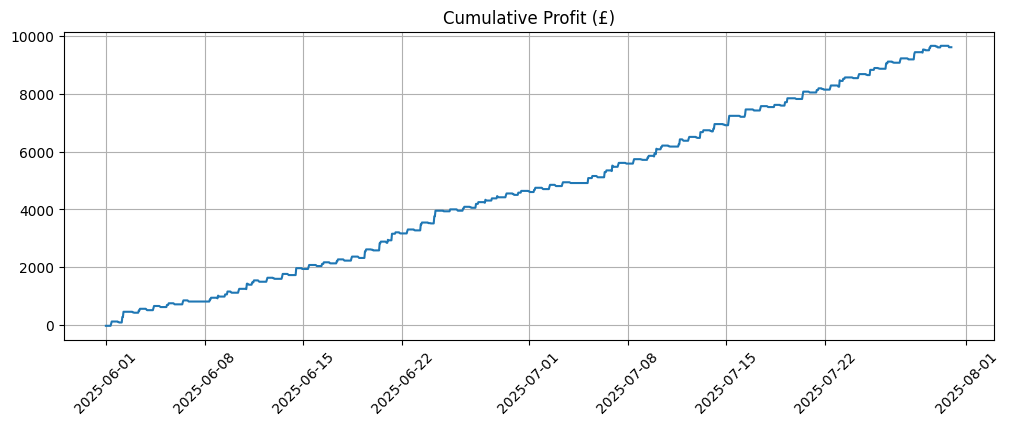

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
file_name = "caseB_grid_battery_market_hourly.csv"
df = pd.read_csv(file_name)

# Time and price
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["price_gbp_per_kwh"] = df["day_ahead_price_gbp_per_mwh"] / 1000.0

# Battery parameters
dt = 1.0
capacity_kwh = 2000.0
p_charge_max_kw = 1000.0
p_discharge_max_kw = 1000.0
eta_ch = 0.938
eta_dis = 0.938
soc_init = 1000.0
soc_min = 0.0
soc_max = capacity_kwh

# Smarter thresholds
low_threshold = df["price_gbp_per_kwh"].quantile(0.20)
high_threshold = df["price_gbp_per_kwh"].quantile(0.80)

n = len(df)
soc = np.zeros(n + 1)
soc[0] = soc_init
charge_kw = np.zeros(n)
discharge_kw = np.zeros(n)
profit_gbp = np.zeros(n)

for t in range(n):
    price = df.loc[t, "price_gbp_per_kwh"]

    # last 24 hours: try to return toward initial SOC
    hours_left = n - t

    if hours_left <= 24:
        if soc[t] < soc_init and price < df["price_gbp_per_kwh"].median():
            c = min(p_charge_max_kw, (soc_max - soc[t]) / eta_ch)
            d = 0
        elif soc[t] > soc_init and price > df["price_gbp_per_kwh"].median():
            d = min(p_discharge_max_kw, soc[t] * eta_dis)
            c = 0
        else:
            c = 0
            d = 0
    else:
        if price <= low_threshold and soc[t] < 0.9 * soc_max:
            c = min(p_charge_max_kw, (soc_max - soc[t]) / eta_ch)
            d = 0
        elif price >= high_threshold and soc[t] > 0.1 * soc_max:
            d = min(p_discharge_max_kw, soc[t] * eta_dis)
            c = 0
        else:
            c = 0
            d = 0

    charge_kw[t] = c
    discharge_kw[t] = d

    soc[t + 1] = soc[t] + eta_ch * c * dt - (d / eta_dis) * dt
    soc[t + 1] = min(max(soc[t + 1], soc_min), soc_max)

    profit_gbp[t] = (d * price * dt) - (c * price * dt)

# Save results
df["charge_kw"] = charge_kw
df["discharge_kw"] = discharge_kw
df["soc_kwh"] = soc[:-1]
df["profit_gbp"] = profit_gbp
df["cumulative_profit_gbp"] = df["profit_gbp"].cumsum()

# Summary
total_profit = df["profit_gbp"].sum()
charged_energy_kwh = (df["charge_kw"] * dt).sum()
discharged_energy_kwh = (df["discharge_kw"] * dt).sum()
throughput_kwh = charged_energy_kwh + discharged_energy_kwh
final_soc = soc[-1]

print("Total profit (£):", round(total_profit, 2))
print("Charged energy (kWh):", round(charged_energy_kwh, 2))
print("Discharged energy (kWh):", round(discharged_energy_kwh, 2))
print("Energy throughput (kWh):", round(throughput_kwh, 2))
print("Initial SOC (kWh):", soc_init)
print("Final SOC (kWh):", round(final_soc, 2))

print("SOC within bounds:", ((soc >= 0) & (soc <= soc_max)).all())
print("Charge within bounds:", ((charge_kw >= 0) & (charge_kw <= p_charge_max_kw)).all())
print("Discharge within bounds:", ((discharge_kw >= 0) & (discharge_kw <= p_discharge_max_kw)).all())

# Plots
plt.figure(figsize=(12,4))
plt.plot(df["timestamp"], df["price_gbp_per_kwh"])
plt.title("Day-ahead Price (£/kWh)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["timestamp"], df["soc_kwh"])
plt.title("Battery SOC (kWh)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["timestamp"], df["charge_kw"], label="Charge (kW)")
plt.plot(df["timestamp"], df["discharge_kw"], label="Discharge (kW)")
plt.title("Battery Dispatch (kW)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["timestamp"], df["cumulative_profit_gbp"])
plt.title("Cumulative Profit (£)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()